# Setup

In [2]:
# forcing determinism

import os, random, numpy as np, torch
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [3]:
# importing all needed packages

#!pip install bertopic
from bertopic import BERTopic
from sklearn.cluster import KMeans
import pandas as pd
from umap import UMAP
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from google.colab import files
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# Loading data

In [4]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
df_orig = pd.read_csv("/content/drive/My Drive/Review.csv")

In [6]:
raw_docs = (df_orig["Title"].astype(str) + " " + df_orig["Abstract Note"].astype(str)).tolist()

In [7]:
# check amount of papers
print(f"Amount: {len(raw_docs)}")

Amount: 1448


# Model init

In [8]:
# Dimensionality Reduction with UMAP
umap_model = UMAP(n_neighbors=10, n_components=8, min_dist=0.0, metric="cosine", random_state=42)

# Clustering with kmeans
cluster_model = KMeans(n_clusters=20, random_state=42, n_init=10)

# Vectorizer model
vectorizer_model = CountVectorizer(min_df=5, max_df=0.85)

#Topic representation with ctfidf model
ctfidf_model = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)

topic_model = BERTopic(
    embedding_model="all-mpnet-base-v2",
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    )

In [9]:
# Model Processing
topics, probs = topic_model.fit_transform(raw_docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Results

In [10]:
topic_info = topic_model.get_topic_info()

# add percentage
total = topic_info['Count'].sum()
topic_info['Percentage'] = np.round(topic_info['Count'] / total * 100,2)

# choose number of words in representation
topic_info["Representation"] = topic_info["Representation"].apply(
    lambda x: ", ".join(x[:3]))

topic_info

,Topic,Count,Name,Representation,Representative_Docs,Percentage
0,0,120,0_territorial_tehran_segregation_densification,"territorial, tehran, segregation",[For whom do we densify? Explaining income var...,8.29
1,1,100,1_healthcare_medical_hospitals_hospital,"healthcare, medical, hospitals",[Population-level trends over a decade in geog...,6.91
2,2,98,2_transport_transit_rail_bus,"transport, transit, rail",[Assessing Public Transit Network Efficiency a...,6.77
3,3,89,3_carbon_ugss_es_ugs,"carbon, ugss, es",[Spatio-Temporal Patterns of Ecosystem Service...,6.15
4,4,88,4_parks_park_recreational_older,"parks, park, recreational",[Explore the recreational service of large urb...,6.08
5,5,88,5_canopy_tree_cover_greenspace,"canopy, tree, cover",[Greenness and equity: Complex connections bet...,6.08
6,6,88,6_ugs_recreation_300_wellbeing,"ugs, recreation, 300",[An elucidation of comparative political ecolo...,6.08
7,7,87,7_air_pollution_pm2_concentrations,"air, pollution, pm2",[Environmental exposure disparities in ultrafi...,6.01
8,8,87,8_gardens_trees_tree_ecosystem,"gardens, trees, tree",[Disentangling the deforestation-environmental...,6.01
9,9,82,9_greenspace_greenery_street_exposure,"greenspace, greenery, street",[Identification of Inequities in Green Visibil...,5.66


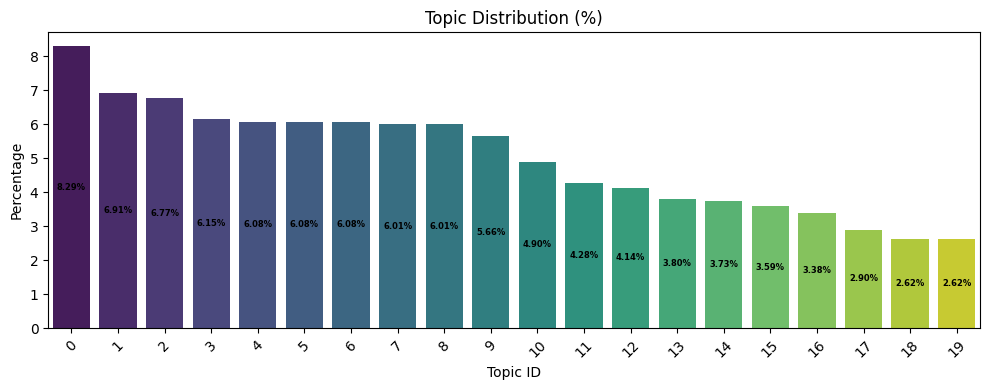

In [11]:
# Sort topics by percentage (optional, for readability)
df_sorted = topic_info.sort_values("Percentage", ascending=False)

plt.figure(figsize=(10,4))
ax = sns.barplot(x="Topic", y="Percentage", data=df_sorted, palette="viridis")

# Annotate inside bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha="center", va="center", fontsize=6, color="black", weight="bold")

plt.title("Topic Distribution (%)")
plt.ylabel("Percentage")
plt.xlabel("Topic ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization

In [12]:
embeddings = topic_model.embedding_model.embed(raw_docs)

In [39]:
# Reduce dimensionality of embeddings (for less runtime)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

# for version without custom labels: delete or set to # the custom labels parts and in visualize_documents the topics=topics and custom_labels=

# applying custom labels for readability
custom_labels = {
    0: "Climate_Policy",
    1: "Urban_Justice",
    2: "Green_Infrastructure",
    3: "Health_Equity",
    4: "Mobility_Transport",
    5: "Whatever",
    6: "Test",
    7: "Test2",
    8: "asdf",
    9: "kitty",
    10: "asewelrk",
    11: "helli",
    12: "hey",
    13: "hi",
    14: "what",
    15: "you",
    16: "this",
    17: "that",
    18: "suomi",
    19: "sininen",
}

topic_model.topic_labels=custom_labels
print(topic_model.topic_labels)

# visualizing documents and topics
topic_model.visualize_documents(raw_docs,
                                #topics=topics,
                                reduced_embeddings=reduced_embeddings,
                                #custom_labels=topic_model.topic_labels,
                                hide_document_hover=True)


{0: 'Climate_Policy', 1: 'Urban_Justice', 2: 'Green_Infrastructure', 3: 'Health_Equity', 4: 'Mobility_Transport', 5: 'Whatever', 6: 'Test', 7: 'Test2', 8: 'asdf', 9: 'kitty', 10: 'asewelrk', 11: 'helli', 12: 'hey', 13: 'hi', 14: 'what', 15: 'you', 16: 'this', 17: 'that', 18: 'suomi', 19: 'sininen'}


In [15]:
# visualizing topics

topic_model.visualize_topics()

In [16]:
# visualizing topic hierarchy 1: hierarchical clustering

topic_model.visualize_hierarchy()

In [17]:
# visualizing topic hierarchy 2: text-based topic tree

hierarchical_topics = topic_model.hierarchical_topics(raw_docs)
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

100%|██████████| 19/19 [00:00<00:00, 231.53it/s]

.
├─healthcare_heat_air_risk_pollution
│    ├─■──flood_risk_gi_stormwater_hazard ── Topic: 18
│    └─healthcare_heat_air_pollution_tree
│         ├─gardens_tehran_segregation_nature_ecosystem
│         │    ├─■──gentrification_visitation_parks_park_latino ── Topic: 14
│         │    └─gardens_tehran_segregation_ecosystem_trees
│         │         ├─gardens_ecosystem_trees_ugs_nature
│         │         │    ├─■──gardens_trees_tree_ecosystem_biodiversity ── Topic: 8
│         │         │    └─■──ugs_recreation_300_wellbeing_neighbourhoods ── Topic: 6
│         │         └─■──territorial_tehran_segregation_densification_settlements ── Topic: 0
│         └─healthcare_heat_air_pollution_medical
│              ├─healthcare_medical_hospitals_covid_emergency
│              │    ├─■──healthcare_medical_hospitals_hospital_care ── Topic: 1
│              │    └─■──covid_food_testing_emergency_response ── Topic: 11
│              └─heat_air_pollution_energy_pm2
│                   ├─heat_air_ener

# Qualitative sampling (medoids)

In [18]:
n_medoid = 3
topics_array = np.array(topics)

poster_children = []
topic_topn_lookup = {}

for topic_id in sorted(set(topics_array)):
    doc_indices = np.where(topics_array == topic_id)[0]
    topic_embs = embeddings[doc_indices]

    if len(doc_indices) == 0:
        continue

    # cosine similarity via cosine distance
    sims = 1 - pairwise_distances(topic_embs, metric="cosine")
    avg_sims = sims.mean(axis=1)

    ranked_local = np.argsort(-avg_sims)
    top_local = ranked_local[:n_medoid]

    top_titles = []

    for rank, local_idx in enumerate(top_local, start=1):
        global_idx = doc_indices[local_idx]

        poster_children.append((global_idx, rank))

In [19]:
poster_lookup = {doc_idx: rank for doc_idx, rank in poster_children}

In [20]:
topic_info = topic_model.get_topic_info()
topic_name_lookup = {
    topic_id: ", ".join([word for word, _ in topic_model.get_topic(topic_id)[:3]])
    for topic_id in topic_info["Topic"]
}

In [21]:
topic_rep_lookup = {}

for topic_id in topic_info["Topic"]:
    words = topic_model.get_topic(topic_id)
    representation = ", ".join([word for word, _ in words[:5]])
    topic_rep_lookup[topic_id] = representation

In [22]:
rows = []

for idx, row in df_orig.iterrows():

    topic_id = topics_array[idx]

    rows.append({
        "Title": row["Title"],
        "Topic_ID": topic_id,
        "Topic_Name": topic_name_lookup.get(topic_id, ""),
        "Topic_Representation": topic_rep_lookup.get(topic_id, ""),
        "Medoid_Rank": poster_lookup.get(idx, "")
    })

df_csv = pd.DataFrame(rows)

df_csv = df_csv.sort_values(
    ["Topic_ID", "Medoid_Rank"],
    ascending=[True, True]
).reset_index(drop=True)

In [23]:
csv_path = "papers_with_topics_and_medoids.csv"
df_csv.to_csv(csv_path, index=False)

files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test section

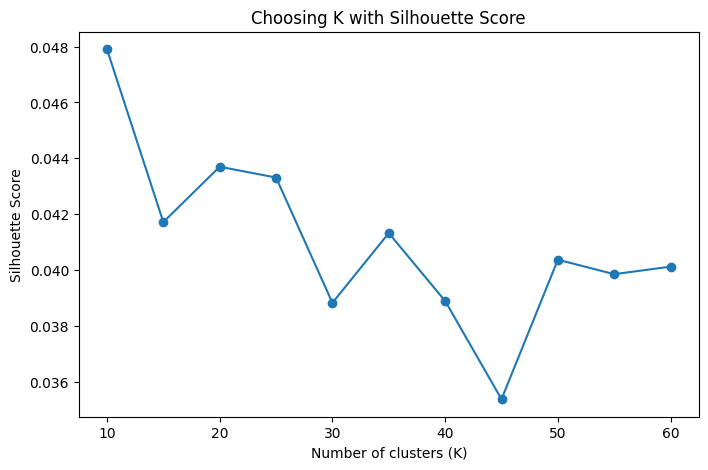

Best K according to silhouette score: 10


In [24]:
# testing for optimal number of topics with silhouette score

k_values = range(10, 61, 5)  # Test K from 10 to 60
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    sil_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Choosing K with Silhouette Score")
plt.show()

# Best K
best_k = k_values[np.argmax(sil_scores)]
print("Best K according to silhouette score:", best_k)
